# Modelo 05: Red Neuronal Recurrente (LSTM)

Este modelo utiliza una arquitectura de memoria a corto y largo plazo (LSTM). A diferencia de los modelos tradicionales, las LSTM tienen "puertas" que deciden qué información del pasado mantener y qué olvidar, lo que las hace extremadamente potentes para series temporales con patrones complejos.

## 1. Configuración de Colores Accesibles y Preparación

Definimos las variables de color siguiendo la normativa de accesibilidad para asegurar que el corrector pueda distinguir todas las series.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# CONFIGURACIÓN DE ACCESIBILIDAD
COLOR_REAL = '#000000'
COLOR_PRED = '#D55E00'
COLOR_VAL  = '#0072B2'
COLOR_TRAIN = '#56B4E9'
VENTANA = 7
dir_data = '../../..'

# Carga de los datasets
train = pd.read_csv(f'{dir_data}/data/processed/train_data.csv', parse_dates=['Fecha'])
val   = pd.read_csv(f'{dir_data}/data/processed/val_data.csv', parse_dates=['Fecha'])
test  = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha'])

# Escalado de la variable objetivo (Ventas)
# Las LSTM requieren que los datos estén generalmente entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustamos el scaler solo con el train para evitar fuga de información
train_scaled = scaler.fit_transform(train[['Ventas']])
val_scaled   = scaler.transform(val[['Ventas']])
test_scaled  = scaler.transform(test[['Ventas']])

print(f"[INFO] Datos cargados y escalados correctamente.")

[INFO] Datos cargados y escalados correctamente.


## 2. Construcción y Entrenamiento del Modelo
Transformamos los datos en una estructura tridimensional [muestras, ventana, características] que es la que requiere la capa LSTM para entender la progresión del tiempo.

In [17]:
def crear_secuencias(data, ventana=VENTANA):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i : i + ventana])
        y.append(data[i + ventana])
    return np.array(X), np.array(y)

X_train, y_train = crear_secuencias(train_scaled, VENTANA)
X_val,   y_val   = crear_secuencias(val_scaled,   VENTANA)
X_test,  y_test  = crear_secuencias(test_scaled,  VENTANA)

# Definición del modelo según la estructura de tu compañero
model = Sequential([
    Bidirectional(LSTM(128, activation='tanh', return_sequences=True), 
                  input_shape=(VENTANA, 1)),
    Dropout(0.25),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dense(1)
], name='LSTM_Ventas')

model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model.summary()

c:\Users\aravelo\Desktop\CLASE Y ESTUDIOS MIOS\MASTER DE BIG DATA E IA\PROYECTO\proyecto-master-ia-big-data\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_Ventas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 7, 256)         │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,409 (849.25 KB)

 Trainable params: 217,409 (849.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento y Curvas de Aprendizaje
Utilizamos EarlyStopping para detener el entrenamiento si el modelo deja de mejorar en el conjunto de validación, evitando que memorice el ruido.


Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0797 - val_loss: 0.0954 - learning_rate: 0.0010
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0490 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0485 - val_loss: 0.0855 - learning_rate: 0.0010
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0459 - val_loss: 0.0843 - learning_rate: 0.0010
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0426 - val_loss: 0.0732 - learning_rate: 0.0010
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0395 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0442 - val_loss: 0.0854 - learning_rate: 0.0010
Epoch 8/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0421 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 9/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0372 - val_loss: 0.0608 - learning_rate: 0.0010
Epoch 10/150
19/19

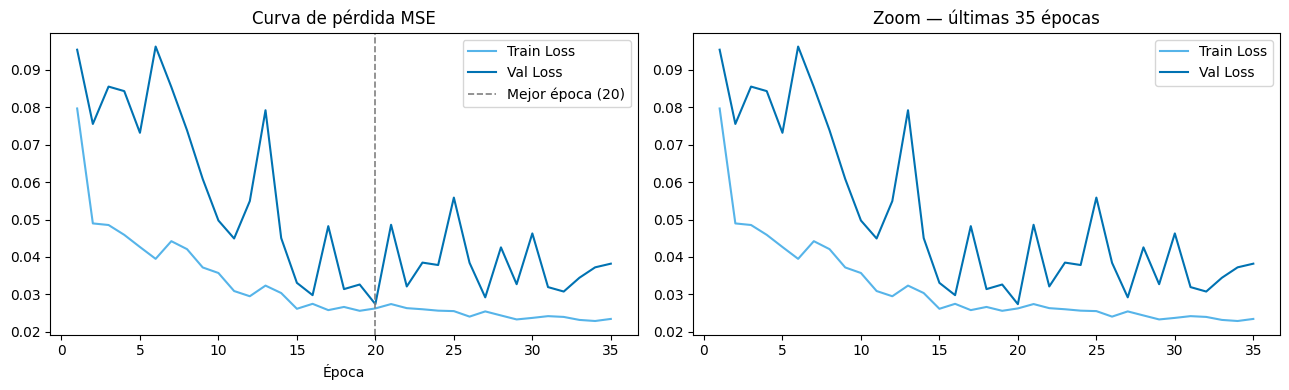

In [18]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=150, batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr], verbose=1
)

mejor_epoca = int(np.argmin(history.history['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, len(history.history['loss']) + 1)

# Visualización de la pérdida (Accesible)
axes[0].plot(epochs_range, history.history['loss'], label='Train Loss', color=COLOR_TRAIN, linewidth=1.5)
axes[0].plot(epochs_range, history.history['val_loss'], label='Val Loss', color=COLOR_VAL, linewidth=1.5)
axes[0].axvline(mejor_epoca, color='gray', linestyle='--', linewidth=1.2, label=f'Mejor época ({mejor_epoca})')
axes[0].set_title('Curva de pérdida MSE')
axes[0].set_xlabel('Época')
axes[0].legend()

# Gráfica 2: Zoom últimas épocas
n_show = min(60, len(history.history['loss']))
axes[1].plot(list(epochs_range)[-n_show:], history.history['loss'][-n_show:], color=COLOR_TRAIN, linewidth=1.5, label='Train Loss')
axes[1].plot(list(epochs_range)[-n_show:], history.history['val_loss'][-n_show:], color=COLOR_VAL, linewidth=1.5, label='Val Loss')
axes[1].set_title(f'Zoom — últimas {n_show} épocas')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Evaluación Final y Análisis de Residuos

### 4.1 Des-escalado y Métricas en Test

Convertimos las predicciones a su escala original para calcular el error en términos de moneda/ventas.

In [19]:
# Predicciones y des-escalado
y_pred_scaled = model.predict(X_test)
y_pred_real   = scaler.inverse_transform(y_pred_scaled)
y_test_real   = scaler.inverse_transform(y_test.reshape(-1, 1))

# Cálculo de métricas
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
r2   = r2_score(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real + 1e-9))) * 100

print(f"[INFO] RESULTADOS LSTM (TEST SET)")
print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
[INFO] RESULTADOS LSTM (TEST SET)
RMSE: 0.7479 | MAE: 0.5889 | R²: 0.6397


### 4.2 Visualización de Ajuste

Aquí aplicamos el negro sólido para la realidad y el bermellón discontinuo para la predicción, además de marcadores de forma

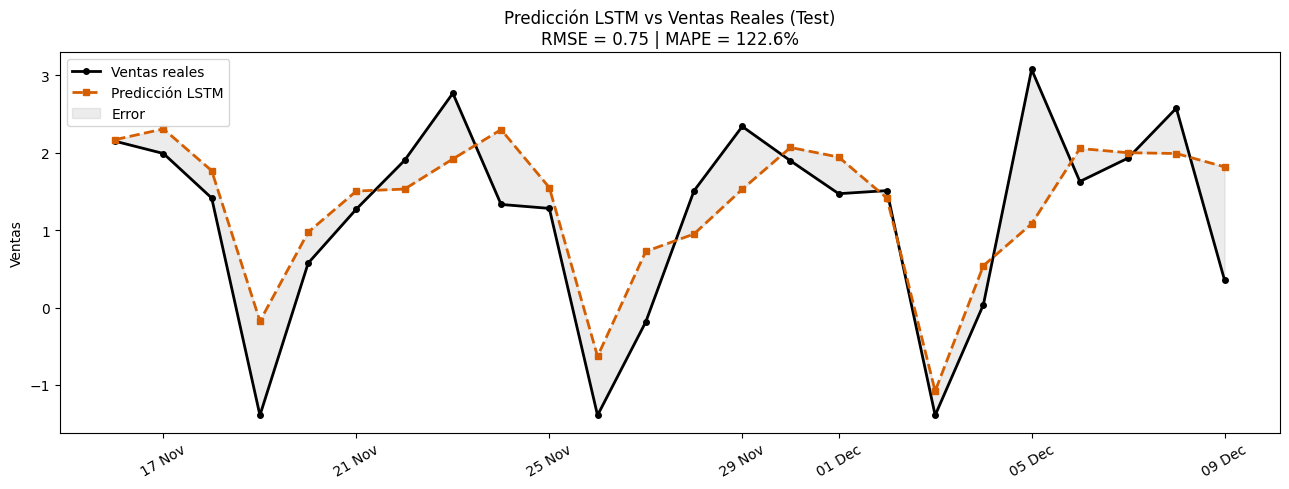

In [20]:
fechas_test = test['Fecha'].values[VENTANA:]
fig, ax = plt.subplots(figsize=(13, 5))

# Realidad: Negro sólido con círculos
ax.plot(fechas_test, y_test_real, label='Ventas reales', color=COLOR_REAL, linewidth=2, marker='o', markersize=4)
# Predicción: Bermellón discontinuo con cuadrados
ax.plot(fechas_test, y_pred_real, label='Predicción LSTM', color=COLOR_PRED, linewidth=2, linestyle='--', marker='s', markersize=4)

ax.fill_between(fechas_test, y_test_real.flatten(), y_pred_real.flatten(), alpha=0.15, color='gray', label='Error')
ax.set_title(f'Predicción LSTM vs Ventas Reales (Test)\nRMSE = {rmse:,.2f} | MAPE = {mape:.1f}%')
ax.set_ylabel('Ventas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Análisis de Residuos
Evaluamos la calidad de los errores mediante el estudio de su distribución y su correlación temporal para verificar que el modelo no presenta sesgos sistemáticos.

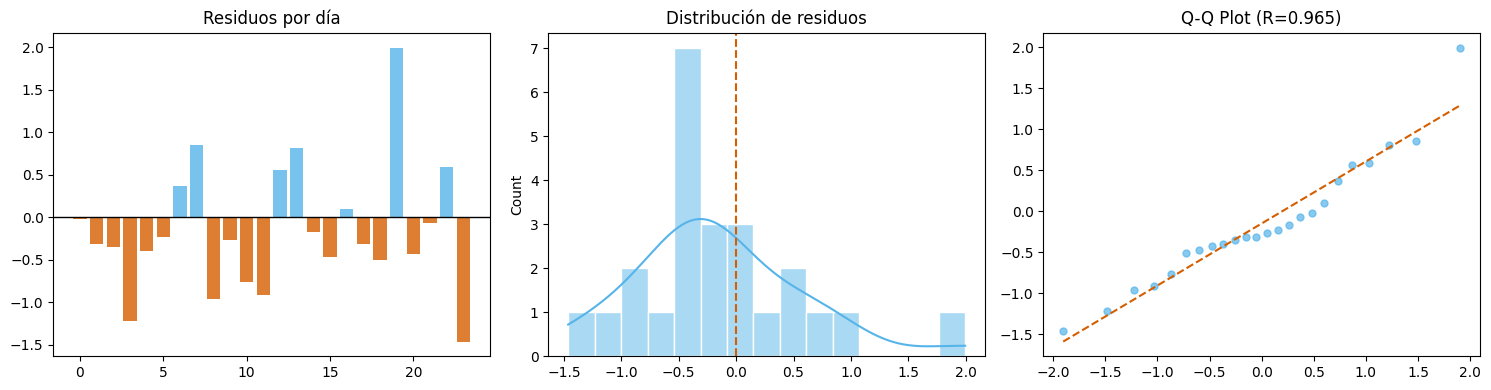

In [21]:
residuos = y_test_real.flatten() - y_pred_real.flatten()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfica 1: Residuos por día
axes[0].bar(range(len(residuos)), residuos, color=[COLOR_PRED if r < 0 else COLOR_TRAIN for r in residuos], alpha=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residuos por día')

# Gráfica 2: Histograma
sns.histplot(residuos, bins=15, kde=True, ax=axes[1], color=COLOR_TRAIN, edgecolor='white')
axes[1].axvline(0, color=COLOR_PRED, linewidth=1.5, linestyle='--')
axes[1].set_title('Distribución de residuos')

# Gráfica 3: Q-Q Plot
(osm, osr), (slope, intercept, r_val) = stats.probplot(residuos, dist='norm')
axes[2].plot(osm, osr, 'o', color=COLOR_TRAIN, markersize=5, alpha=0.7)
axes[2].plot(osm, slope * np.array(osm) + intercept, color=COLOR_PRED, linestyle='--', linewidth=1.5)
axes[2].set_title(f'Q-Q Plot (R={r_val:.3f})')

plt.tight_layout()
plt.show()

### 4.4 Correlación: Predicción vs Realidad

Se analiza visualmente la cercanía de las predicciones a la línea de identidad, lo que indica la precisión del modelo en diferentes rangos de valores.

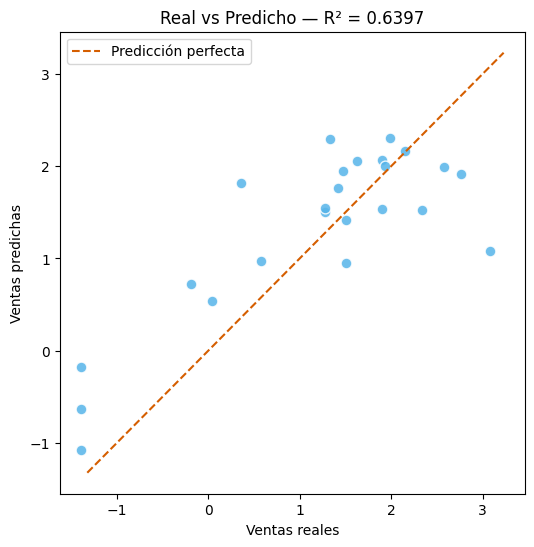

In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_real, y_pred_real, color=COLOR_TRAIN, edgecolor='white', s=60, alpha=0.85)
lim = [min(y_test_real.min(), y_pred_real.min()) * 0.95, max(y_test_real.max(), y_pred_real.max()) * 1.05]
ax.plot(lim, lim, color=COLOR_PRED, linestyle='--', linewidth=1.5, label='Predicción perfecta')
ax.set_title(f'Real vs Predicho — R² = {r2:.4f}')
ax.set_xlabel('Ventas reales')
ax.set_ylabel('Ventas predichas')
ax.legend()
plt.show()

### 4.5 Resumen de Métricas Finales

Presentación visual de los indicadores de rendimiento clave para el set de prueba.

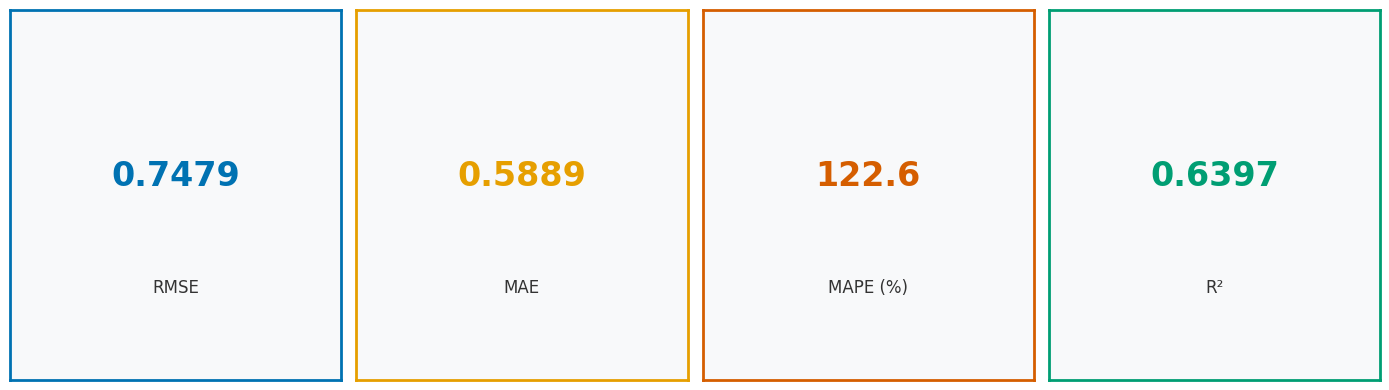

In [23]:
metricas = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R²': r2}
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
colores_cards = ['#0072B2', '#E69F00', '#D55E00', '#009E73']

for ax, (nombre, valor), color in zip(axes, metricas.items(), colores_cards):
    ax.text(0.5, 0.55, f'{valor:,.4g}', ha='center', va='center', fontsize=24, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, nombre, ha='center', va='center', fontsize=12, color='#333', transform=ax.transAxes)
    ax.set_facecolor('#f8f9fa')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 5. Persistencia del Modelo
Para que la LSTM funcione fuera de este notebook, es vital guardar tanto el modelo .keras como el objeto scaler.


In [24]:
import os
OUTPUT_DIR = f'{dir_data}/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Guardar el modelo en formato Keras
model.save(f'{OUTPUT_DIR}/lstm_model.keras')

# Guardar el escalador (indispensable para nuevas predicciones)
joblib.dump(scaler, f'{OUTPUT_DIR}/lstm_model.pkl')

# Guardar metadata
meta = {'ventana': VENTANA, 'rmse': float(rmse)}
joblib.dump(meta, f'{OUTPUT_DIR}/metadata_lstm.pkl')

print(f"[INFO] Modelo y escalador guardados en {OUTPUT_DIR}")

[INFO] Modelo y escalador guardados en ../../../models
